In [ ]:
# %pip install -q -U \
#   "torch" \
#   "torchvision" \
#   "torchaudio" \
#   "triton==3.1.0" \
#   "transformers==4.48.3" \
#   "accelerate==0.34.2" \
#   "peft==0.13.2" \
#   "bitsandbytes==0.45.5"

In [1]:
import json
import re
from pathlib import Path
import torch
from dataclasses import dataclass
from typing import Any
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen2VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel

#### 1. connect to google drive and unzip dataset

In [8]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
print("Assuming ChartQA_Dataset.zip was downloaded to drive")

# replace the path with your own path
!unzip -q "/content/drive/MyDrive/646_datasets/ChartQA_Dataset.zip" -d /content/

Assuming ChartQA_Dataset.zip was downloaded to drive


In [10]:
mv "/content/ChartQA Dataset" "/content/ChartQA_Dataset"

#### helper

In [11]:
import re
from pathlib import Path

def normalize_em(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def exact_match(pred: str, gold: str) -> bool:
    return normalize_em(pred) == normalize_em(gold)

def inspect_chartqa_predictions(records: list[dict], split: str = "test", max_show: int = 5, chartqa_root: Path | None = None):
    root = chartqa_root if chartqa_root is not None else Path("/content/ChartQA_Dataset")
    for n in range(min(max_show, len(records))):
        ex = records[n]
        print(ex["question"][:80], "...", ex["gold"], ex["pred"])
        image_path = root / split / "png" / ex["imgname"]
        image = Image.open(image_path)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Q: {ex['question'][:100]}{'…' if len(ex['question']) > 100 else ''}\n"
                  f"A: {ex['gold']} | pred: {ex['pred']} | EM:{ex['exact_match']}", fontsize=9)
        plt.show()

#### Step 2 — Load data (ChartQA)


In [12]:
# --- CELL 4: Dataset Classes & Collators ---

# Prompts
ANSWER_ONLY_PROMPT = "\nAnswer with only the final answer: a short phrase or a number. No explanation."
Baseline_PROMPT = ANSWER_ONLY_PROMPT
SFT_SYSTEM_PROMPT = ANSWER_ONLY_PROMPT

def build_train_messages(question: str, answer: str) -> list[dict]:
    return [
        {"role": "system", "content": [{"type": "text", "text": SFT_SYSTEM_PROMPT}]},
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": question}]},
        {"role": "assistant", "content": [{"type": "text", "text": str(answer)}]},
    ]

def _answer_to_str(label) -> str:
    if isinstance(label, list): return str(label[0]) if len(label) > 0 else ""
    return str(label) if label is not None else ""

class ChartQAHumanDataset(Dataset):
    def __init__(self, split_dir: str | Path, json_name: str = "train_human.json"):
        self.split_dir = Path(split_dir)
        self.png_dir = self.split_dir / "png"
        with open(self.split_dir / json_name, encoding="utf-8") as f:
            self.items = json.load(f)

    def __len__(self) -> int: return len(self.items)

    def __getitem__(self, idx: int) -> dict:
        row = self.items[idx]
        imgname = row["imgname"]

        # Load and resize the image to a smaller max dimension
        image = Image.open(self.png_dir / imgname).convert("RGB")
        image.thumbnail((768, 768)) # Add this line to shrink large charts

        return {"image": image, "question": row["query"], "answer": _answer_to_str(row.get("label")), "imgname": imgname}

def chartqa_human_collate_fn(batch: list[dict]) -> dict:
    return {
        "images": [b["image"] for b in batch], "questions": [b["question"] for b in batch],
        "answers": [b["answer"] for b in batch], "imgnames": [b["imgname"] for b in batch],
    }

class ChartQASFTDataset(Dataset):
    def __init__(self, base_ds: Dataset, max_samples: int | None = None):
        self.base_ds = base_ds
        self.max_samples = len(base_ds) if max_samples is None else min(max_samples, len(base_ds))

    def __len__(self): return self.max_samples

    def __getitem__(self, idx):
        ex = self.base_ds[idx]
        return {"image": ex["image"], "messages": build_train_messages(ex["question"], ex["answer"])}

@dataclass
class Qwen2VLAnswerOnlyCollator:
    processor: Any
    max_length: int = 1024

    def __call__(self, features: list[dict]) -> dict[str, torch.Tensor]:
        full_texts, prompt_texts, images = [], [], []
        for ex in features:
            full_conv = ex["messages"]
            prompt_conv = full_conv[:-1]
            full_texts.append(self.processor.apply_chat_template(full_conv, tokenize=False, add_generation_prompt=False))
            prompt_texts.append(self.processor.apply_chat_template(prompt_conv, tokenize=False, add_generation_prompt=True))
            images.append(ex["image"])

        model_inputs = self.processor(text=full_texts, images=images, padding=True, truncation=True, max_length=self.max_length, return_tensors="pt")
        prompt_inputs = self.processor(text=prompt_texts, images=images, padding=True, truncation=True, max_length=self.max_length, return_tensors="pt")

        labels = model_inputs["input_ids"].clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        for i in range(labels.size(0)):
            prompt_len = int(prompt_inputs["attention_mask"][i].sum().item())
            labels[i, :prompt_len] = -100

        model_inputs["labels"] = labels
        return model_inputs

In [16]:
# --- CELL 5: Initialize DataLoaders ---
CHARTQA_ROOT = Path("/content/ChartQA_Dataset")

# Base Datasets
train_ds = ChartQAHumanDataset(CHARTQA_ROOT / "train", json_name="train_human.json")
val_ds = ChartQAHumanDataset(CHARTQA_ROOT / "val", json_name="val_human.json")
test_ds = ChartQAHumanDataset(CHARTQA_ROOT / "test", json_name="test_human.json")

# Base DataLoaders (for testing inference)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0, collate_fn=chartqa_human_collate_fn)

print("Base Dataset Sizes - Train:", len(train_ds), " Val:", len(val_ds), " Test:", len(test_ds))

Base Dataset Sizes - Train: 7398  Val: 960  Test: 1250


#### Step 3 — Load base model (Qwen2-VL)


In [ ]:
# --- CELL 6: Load Base Model & Apply LoRA ---

from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

processor = AutoProcessor.from_pretrained(MODEL_ID)

# Load Model
model_lora = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

# Freeze vision tower
if hasattr(model_lora, "visual"):
    for p in model_lora.visual.parameters():
        p.requires_grad = False

# Attach LoRA adapters
model_lora = prepare_model_for_kbit_training(model_lora)
lora_config = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)
model_lora = get_peft_model(model_lora, lora_config)

if hasattr(model_lora, "enable_input_require_grads"):
    model_lora.enable_input_require_grads()

def print_trainable_parameters(model):
    trainable, total = 0, 0
    for _, p in model.named_parameters():
        total += p.numel()
        if p.requires_grad: trainable += p.numel()
    print(f"trainable params: {trainable:,} / {total:,} ({100*trainable/total:.4f}%)")

print_trainable_parameters(model_lora)

#### Step 4. Training
This section is entirely dedicated to preparing the SFT dataloader for training and running the HuggingFace Trainer.


In [10]:
# --- CELL 7: Fine-Tuning ---
from datetime import datetime

MAX_TRAIN_SAMPLES = None  # adjust as needed
MAX_VAL_SAMPLES = 40
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"/content/qwen2vl_2b_chartqa_lora_from_base_{timestamp}"

# Training Data
train_sft_ds = ChartQASFTDataset(train_ds, max_samples=MAX_TRAIN_SAMPLES)
val_sft_ds = ChartQASFTDataset(val_ds, max_samples=MAX_VAL_SAMPLES)
collator = Qwen2VLAnswerOnlyCollator(processor, max_length=1024)

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    logging_steps=10,
    eval_steps=100,
    save_steps=100,
    eval_strategy="steps",
    save_strategy="steps",
    save_total_limit=2,
    bf16=torch.cuda.is_available(),
    fp16=False,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    remove_unused_columns=False,
    report_to="none",
)

trainer = Trainer(
    model=model_lora,
    args=args,
    train_dataset=train_sft_ds,
    eval_dataset=val_sft_ds,
    data_collator=collator,
)

trainer.train()
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Saved LoRA adapter to:", OUTPUT_DIR)

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss,Validation Loss
100,0.426000,0.799596
200,0.461711,0.780310
300,0.416836,0.778441
400,0.453332,0.762638
500,0.482514,0.774491
600,0.444774,0.746592
700,0.483842,0.743608
800,0.405726,0.740103
900,0.368198,0.741991


Saved LoRA adapter to: /content/qwen2vl_2b_chartqa_lora_from_base_20260423_052019


#### Step 5. Testing and Evaluation
The final section holds the large evaluation loop and executes tests for both the baseline model and your newly trained LoRA model.

In [14]:
# --- CELL 8: Inference Logic ---

def run_chartqa_inference(data, model, processor, device, prompt: str, dataset_name: str, save_file: bool=False, max_samples: int|None=None, max_new_tokens: int=128):
    dataloader = data if isinstance(data, DataLoader) else DataLoader(data, batch_size=1, shuffle=False, collate_fn=chartqa_human_collate_fn)
    n_target = len(dataloader.dataset) if max_samples is None else min(max_samples, len(dataloader.dataset))

    records, correct, n_done = [], 0, 0

    for batch in tqdm(dataloader, desc=f"{dataset_name} inference"):
        if n_done >= n_target: break
        take = min(len(batch["images"]), n_target - n_done)
        if take <= 0: break

        images, questions, answers, imgnames = batch["images"][:take], batch["questions"][:take], batch["answers"][:take], batch["imgnames"][:take]
        text_prompts = []

        for j in range(take):
            conversation = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": questions[j] + prompt}]}]
            text_prompts.append(processor.apply_chat_template(conversation, add_generation_prompt=True))

        inputs = processor(text=text_prompts, images=images, padding=True, return_tensors="pt").to(device)

        with torch.inference_mode():
            output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)

        preds = processor.batch_decode(output_ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

        for j in range(take):
            pred, gold = preds[j].strip(), answers[j]
            ok = exact_match(pred, gold)
            correct += int(ok)
            records.append({"imgname": imgnames[j], "question": questions[j], "gold": gold, "pred": pred, "exact_match": ok})
            n_done += 1

    em = correct / n_done if n_done else 0.0
    print(f"[{dataset_name}] EM ({n_done} examples): {em:.4f}")

    if save_file:
        out_path = Path(f"2_LoRA_{dataset_name}_accuracy_{em:.4f}.jsonl")
        with open(out_path, "w", encoding="utf-8") as f:
            for r in records: f.write(json.dumps(r, ensure_ascii=False) + "\n")
    return em, records

In [7]:
from peft import PeftModel

# Define the path to your saved checkpoint (lora_checkpoints.zip)
CHECKPOINT_PATH = "qwen2vl_2b_chartqa_lora_from_base_20260423_052019"

# Make sure the base model and processor are loaded (from previous cell)
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration
import torch
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model_lora = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

# Load the LoRA adapters onto the base model
model_lora = PeftModel.from_pretrained(model_lora, CHECKPOINT_PATH)

print(f"Model loaded from checkpoint: {CHECKPOINT_PATH}")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Model loaded from checkpoint: qwen2vl_2b_chartqa_lora_from_base_20260423_052019


In [17]:
# --- CELL 9: Run Tests ---

max_samples = None # set to 'None' for testing all cases

# Ensure the model is in evaluation mode (turns off dropout, etc.)
model_lora.eval()

# Test: Evaluate the Fine-Tuned LoRA Model (Adapters are active)
lora_test_em, lora_test_records = run_chartqa_inference(
    test_loader, model_lora, processor, device, Baseline_PROMPT, dataset_name="test_lora", save_file=True, max_samples=max_samples
)
print("LoRA test EM:", lora_test_em)


test_lora inference:   0%|          | 0/1250 [00:00<?, ?it/s]

[test_lora] EM (1250 examples): 0.5208
LoRA test EM: 0.5208



--- BASELINE PREDICTIONS ---
How many food item is shown in the bar graph? ... 14 10


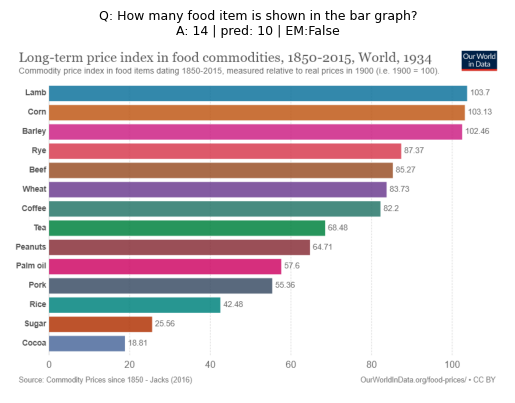

What is the difference in value between Lamb and Corn? ... 0.57 0.97


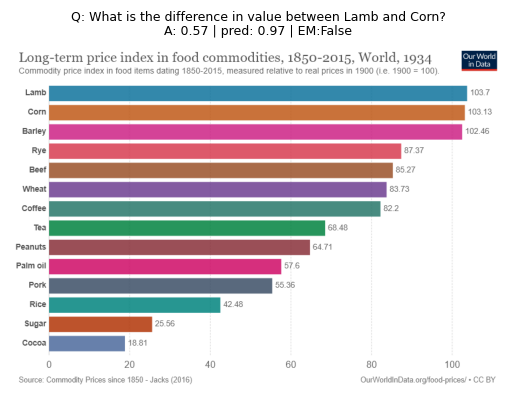

How many bars are shown in the chart? ... 3 3


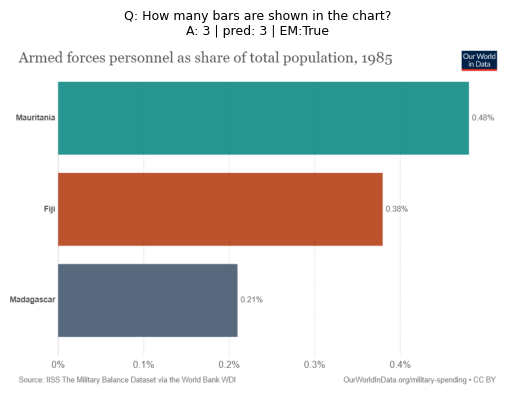

Is the sum value of Madagascar more then Fiji? ... No No


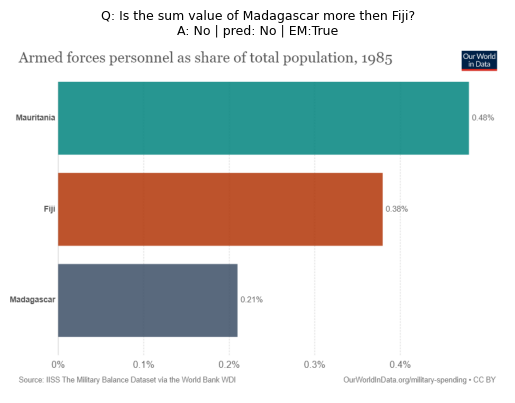

What's the value of the lowest bar? ... 23 23


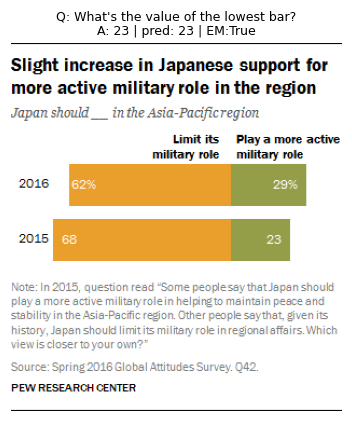

What is the difference between the highest and the lowest green bar?? ... 6 34


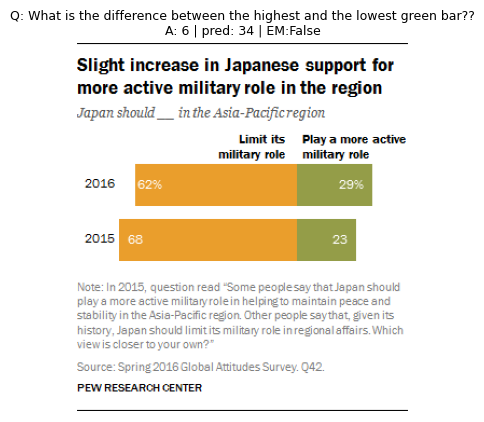

What percent who think of President Donald Trump as Dangerous? ... 62 62


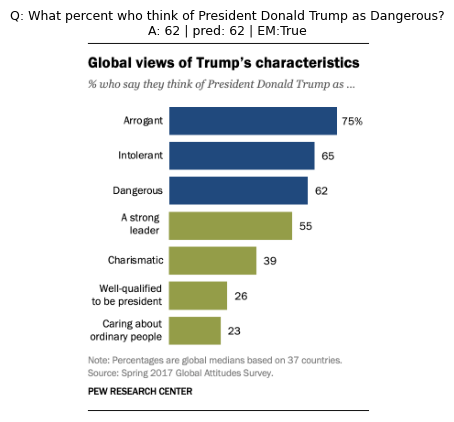

Is the sum of the percents of Charismatic and Well-qualified to be president mor ... Yes No


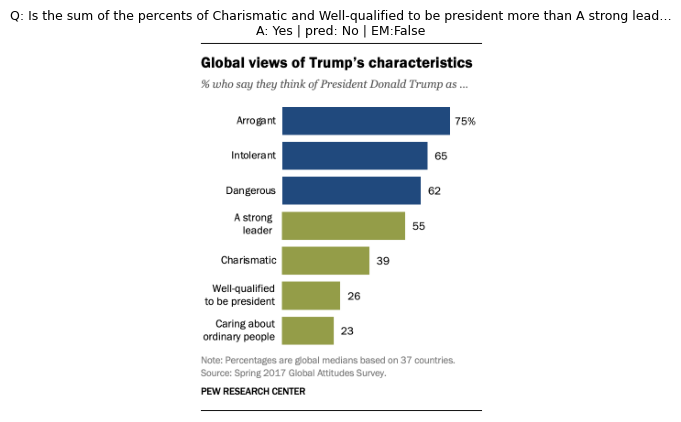

What was the 4th most popular emotion? ... Inspired Inspired


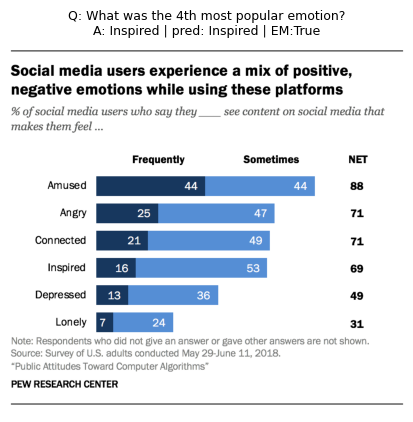

How many more people felt inspired frequently than depressed frequently? ... 0.03 0.23


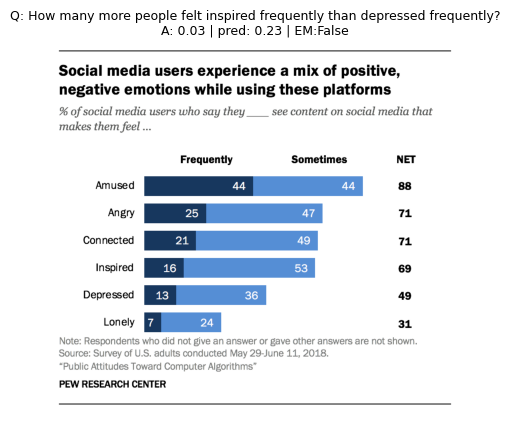


--- LORA PREDICTIONS ---
How many food item is shown in the bar graph? ... 14 10


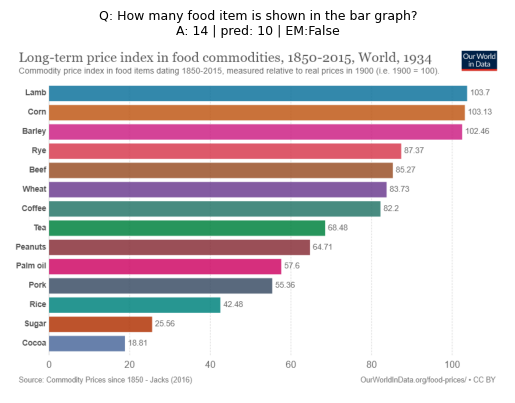

What is the difference in value between Lamb and Corn? ... 0.57 0.39


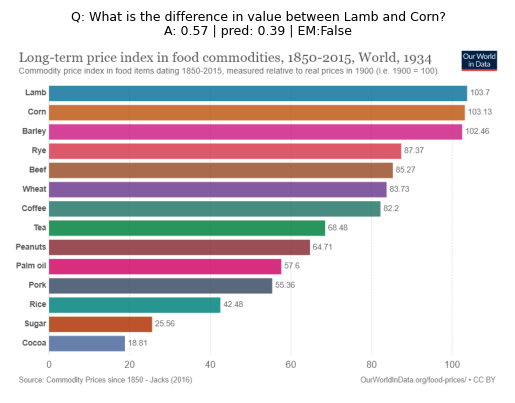

How many bars are shown in the chart? ... 3 3


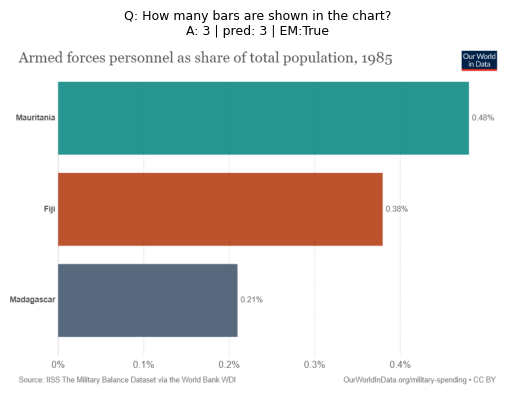

Is the sum value of Madagascar more then Fiji? ... No No


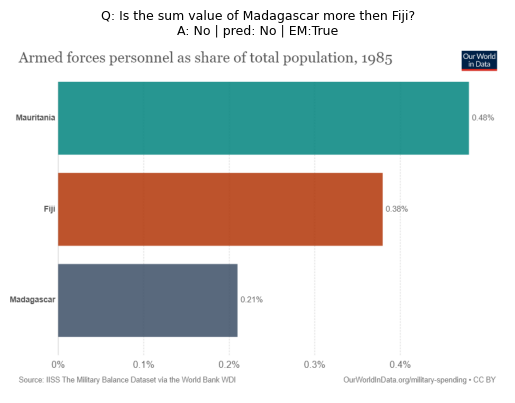

What's the value of the lowest bar? ... 23 23


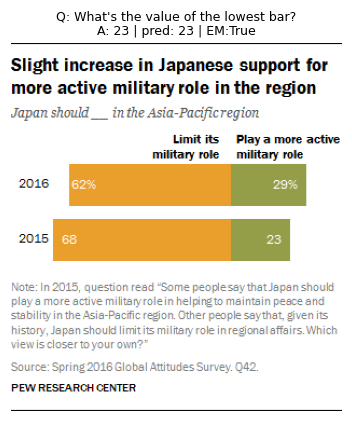

What is the difference between the highest and the lowest green bar?? ... 6 4


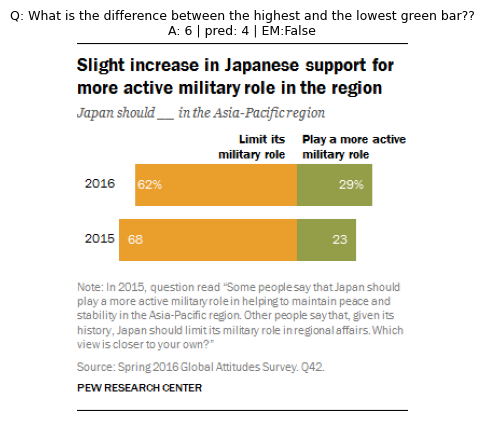

What percent who think of President Donald Trump as Dangerous? ... 62 62


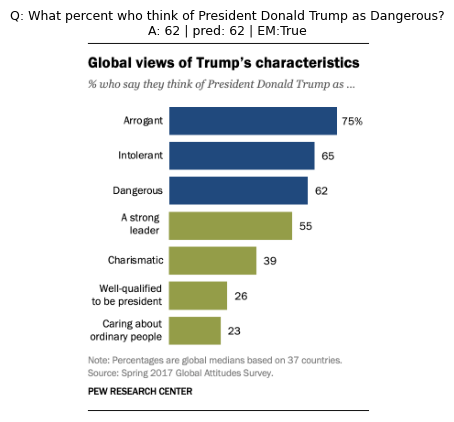

Is the sum of the percents of Charismatic and Well-qualified to be president mor ... Yes No


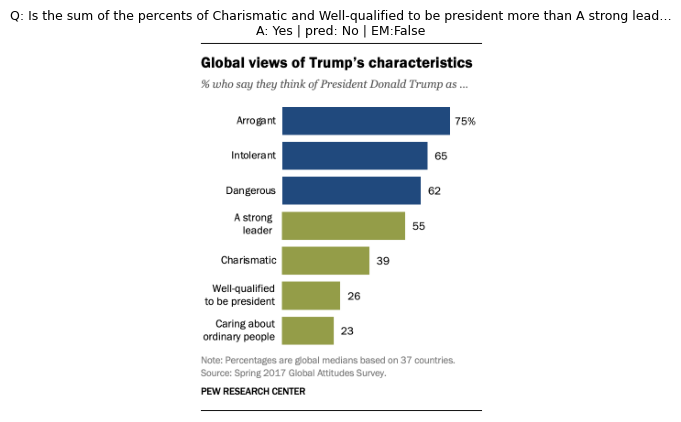

What was the 4th most popular emotion? ... Inspired Inspired


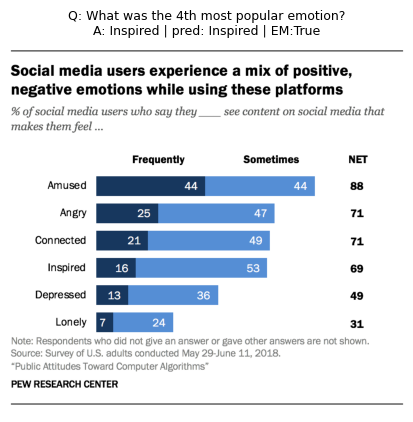

How many more people felt inspired frequently than depressed frequently? ... 0.03 0.23


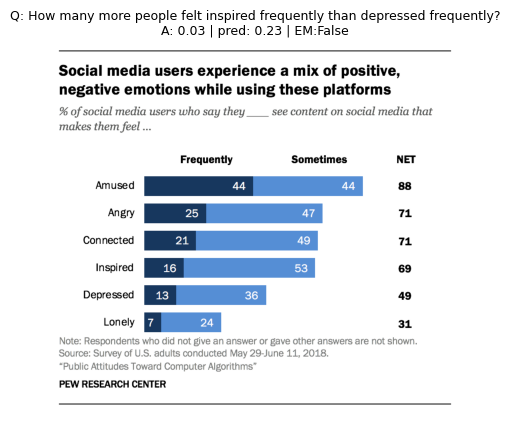

In [ ]:
# Visualize Results
print("\n--- LORA PREDICTIONS ---")
inspect_chartqa_predictions(lora_test_records, split="test", max_show=10)